In [14]:
import csv
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [2]:
perturbation = "DMSO"
held_out = "ADKiCTR"

In [3]:
LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ held_out
PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"

In [4]:
C9 = ['RFTiALS', 'TJViALS', 'EGMiALS', 'LJXiALS']
Ctrl = ['AE8iCTR', 'ZKZiCTR', 'XH7iCTR', 'ADKiCTR', 'NK3iCTR']
SOD1 =  ['BFUiALS', 'KRCiALS', 'ZLMiALS', 'AFGiALS']
sALS = ['CS6EVH', 'CS6ULB', 'CS6WF5', 'CS8JGP']
genotype = {}
for line in C9:
    genotype[line] = "C9"
for line in Ctrl:
    genotype[line] = "Ctrl"
for line in SOD1:
    genotype[line] = "SOD1"
for line in sALS:
    genotype[line] = "sALS with NuP defects"

In [9]:
lines = C9+Ctrl + SOD1 + sALS

In [ ]:
predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])


In [8]:
print(predictions)

     epoch prediction  correct  tie
0        0       Ctrl        1    0
1        1         C9        0    0
2        2       Ctrl        1    0
3        3       Ctrl        1    0
4        4       Ctrl        1    0
..     ...        ...      ...  ...
496    496       Ctrl        1    0
497    497       Ctrl        1    0
498    498       Ctrl        1    0
499    499       Ctrl        1    0
500    500       Ctrl        1    0

[501 rows x 4 columns]


['Ctrl', 'C9']
['Ctrl', 'Ctrl']


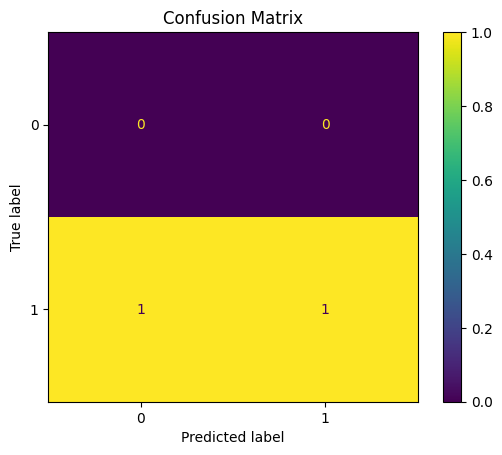

In [ ]:
predicted = []
actual = []
class_names= ["C9","Ctrl"]
lines=["ADKiCTR","AE8iCTR"]
for line in lines:
    LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
    PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
    predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
    predicted_genotype= predictions[-1:]["prediction"].item()
    predicted.append(predicted_genotype)
    actual_genotype = genotype[line]
    actual.append(actual_genotype)
print(predicted)
print(actual)
# 5. Compute the confusion matrix
cm = confusion_matrix(actual, predicted)

# 6. Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

